# 03: Evaluation 

## What this notebook does

The training notebook changed the model's weights. This notebook does **not** train anything. It consideres the trained models and checks whether they work on graphs they did not see during training.


The analysis here performed:

- inspect the held-out test graphs;
- predict which currently active nodes fail next;
- choose the probability threshold using validation data, never test data;
- compare neural networks with simple rules;
- report classification, cascade-size and load errors;
- check whether conclusions change across graph families and cascade regimes;
- add graph-level uncertainty analysis;
- save clean tables for `04_results.ipynb`.

The notebook keeps the most informative parts of the three draft versions. Probability calibration, cost-sensitive thresholds and intervention-budget analysis are moved to the startup notebook, where they have a clearer operational role.


## Imports

Most packages are familiar from the previous notebooks. `sklearn.metrics` is used only to measure predictions; it does not train the PyTorch models.


In [1]:
from __future__ import annotations

import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset


In [2]:
from dl_models import build_model


## Folder Paths

The notebook expects the same `config.yaml`, dataset files and checkpoints created earlier. The output folders are the standard folders read by the final results notebook.


In [3]:
current_folder = Path.cwd().resolve()

if (current_folder / "config.yaml").exists():
    ROOT = current_folder
elif (current_folder / "DL_project" / "config.yaml").exists():
    ROOT = current_folder / "DL_project"
elif (current_folder.parent / "config.yaml").exists():
    ROOT = current_folder.parent
else:
    raise FileNotFoundError(
        "config.yaml was not found. Run this notebook from the DL_project folder."
    )

with (ROOT / "config.yaml").open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

DATA_DIR = ROOT / config["data"]["output_dir"]
CHECKPOINT_DIR = ROOT / "artifacts" / "checkpoints"
EVALUATION_DIR = ROOT / "artifacts" / "evaluation"
PREDICTION_DIR = ROOT / "artifacts" / "predictions"
TABLE_DIR = ROOT / "artifacts" / "results" / "tables"
FIGURE_DIR = ROOT / "artifacts" / "results" / "figures"

for folder in [EVALUATION_DIR, PREDICTION_DIR, TABLE_DIR, FIGURE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

SEED = int(config.get("seed", 42))
BOOTSTRAP_REPETITIONS = 200
MODEL_NAMES = ["mlp", "gnn", "hybrid"]

np.random.seed(SEED)
torch.manual_seed(SEED)

print("Project root:", ROOT)
print("Evaluation outputs:", EVALUATION_DIR)


Project root: /home/riccorte/CIRCLES/DL/DL_project
Evaluation outputs: /home/riccorte/CIRCLES/DL/DL_project/artifacts/evaluation


In [4]:
metadata = json.loads(
    (DATA_DIR / "metadata.json").read_text(encoding="utf-8")
)

train_samples = torch.load(
    DATA_DIR / "train.pt",
    map_location="cpu",
    weights_only=False,
)
validation_samples = torch.load(
    DATA_DIR / "val.pt",
    map_location="cpu",
    weights_only=False,
)
test_samples = torch.load(
    DATA_DIR / "test.pt",
    map_location="cpu",
    weights_only=False,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# These positions are the feature order used in 00_dataset.ipynb.
# If metadata contains names, we use them instead of trusting the positions blindly.
FEATURE_INDEX = {
    "load": 0,
    "load_ratio": 2,
    "failed": 3,
    "degree": 6,
}

feature_names = metadata.get("feature_names", metadata.get("node_feature_names", []))
if isinstance(feature_names, list):
    normalized_names = {
        str(name).strip().lower().replace(" ", "_"): index
        for index, name in enumerate(feature_names)
    }
    for feature_name in list(FEATURE_INDEX):
        if feature_name in normalized_names:
            FEATURE_INDEX[feature_name] = normalized_names[feature_name]

print("Device:", device)
print("Training transitions:", len(train_samples))
print("Validation transitions:", len(validation_samples))
print("Test transitions:", len(test_samples))
print("Feature positions used:", FEATURE_INDEX)


Device: cpu
Training transitions: 1912
Validation transitions: 403
Test transitions: 413
Feature positions used: {'load': 0, 'load_ratio': 2, 'failed': 3, 'degree': 6}


## 3. Check of test set

A graph can generate several consecutive transitions, these corresponds to correlated data. Therefore, we count both transition samples and independent graph IDs.

This plot does not measure model quality. It tells us how much evidence is behind the later scores.


In [5]:
test_composition = pd.DataFrame(
    {
        "graph_id": [int(sample["graph_id"]) for sample in test_samples],
        "family": [sample["family"] for sample in test_samples],
        "regime": [sample["regime"] for sample in test_samples],
        "num_nodes": [int(sample["num_nodes"]) for sample in test_samples],
    }
)

transition_counts = (
    test_composition.groupby(["family", "regime"], as_index=False)
    .size()
    .rename(columns={"size": "transition_samples"})
)

independent_graph_counts = (
    test_composition.drop_duplicates("graph_id")
    .groupby(["family", "regime"], as_index=False)
    .size()
    .rename(columns={"size": "independent_graphs"})
)

split_audit = transition_counts.merge(
    independent_graph_counts,
    on=["family", "regime"],
    how="outer",
).fillna(0)

split_audit.to_csv(TABLE_DIR / "test_split_audit.csv", index=False)
split_audit


,family,regime,transition_samples,independent_graphs
0,ba,local,80,25
1,ba,long_range,56,21
2,er,local,84,24
3,er,long_range,56,20
4,ws,local,60,19
5,ws,long_range,77,26


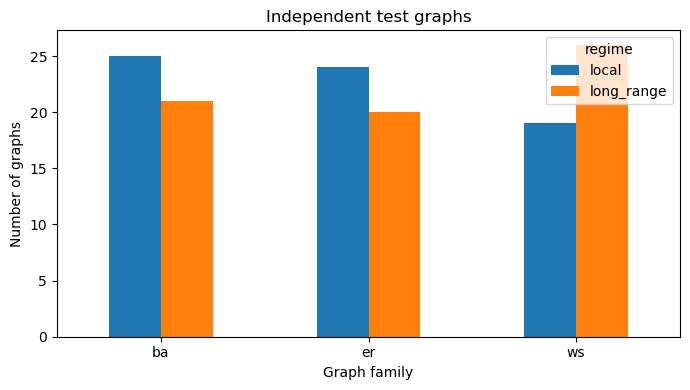

In [6]:
plot_data = (
    test_composition.drop_duplicates("graph_id")
    .groupby(["family", "regime"])
    .size()
    .unstack(fill_value=0)
)

figure, axis = plt.subplots(figsize=(7, 4))
plot_data.plot(kind="bar", ax=axis)
axis.set_title("Independent test graphs")
axis.set_xlabel("Graph family")
axis.set_ylabel("Number of graphs")
axis.tick_params(axis="x", rotation=0)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "test_graph_composition.png", dpi=180)
plt.show()


## Build evaluation batches

Graphs may contain different numbers of nodes. PyTorch prefers rectangular tensors, so smaller graphs are padded with zeros. The Boolean `mask` tells the model and the metrics which positions are real nodes and which positions are only padding.

This repeats the training batching logic so the notebook can run by itself. In a larger codebase, the function is a repetition of the previous notebook and should live in a shared module.


In [7]:
class CascadeDataset(Dataset):
    def __init__(self, samples):
        self.samples = list(samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        return self.samples[index]


def collate_graph_batch(samples):
    """Pad graphs in one mini-batch to the size of the largest graph."""
    batch_size = len(samples)
    max_nodes = max(int(sample["num_nodes"]) for sample in samples)
    feature_dim = int(samples[0]["x"].shape[1])
    positional_dim = int(samples[0]["lap_pe"].shape[1])
    max_distance = int(config["data"]["max_distance"])

    batch = {
        "x": torch.zeros(batch_size, max_nodes, feature_dim),
        "adj": torch.zeros(batch_size, max_nodes, max_nodes),
        "lap_pe": torch.zeros(batch_size, max_nodes, positional_dim),
        "dist": torch.full(
            (batch_size, max_nodes, max_nodes),
            fill_value=max_distance + 1,
            dtype=torch.long,
        ),
        "mask": torch.zeros(batch_size, max_nodes, dtype=torch.bool),
        "y_node": torch.zeros(batch_size, max_nodes),
        "y_load": torch.zeros(batch_size, max_nodes),
        "y_graph": torch.zeros(batch_size),
        "metadata": [],
    }

    for batch_index, sample in enumerate(samples):
        num_nodes = int(sample["num_nodes"])

        batch["x"][batch_index, :num_nodes] = sample["x"]
        batch["adj"][batch_index, :num_nodes, :num_nodes] = sample["adj"]
        batch["lap_pe"][batch_index, :num_nodes] = sample["lap_pe"]
        batch["dist"][batch_index, :num_nodes, :num_nodes] = sample["dist"]
        batch["mask"][batch_index, :num_nodes] = True
        batch["y_node"][batch_index, :num_nodes] = sample["y_node"]
        batch["y_load"][batch_index, :num_nodes] = sample["y_load"]
        batch["y_graph"][batch_index] = sample["y_graph"]

        batch["metadata"].append(
            {
                "num_nodes": num_nodes,
                "graph_id": int(sample["graph_id"]),
                "family": sample["family"],
                "regime": sample["regime"],
            }
        )

    return batch


def make_loader(samples):
    return DataLoader(
        CascadeDataset(samples),
        batch_size=int(config["training"]["batch_size"]),
        shuffle=False,
        collate_fn=collate_graph_batch,
    )


def move_batch_to_device(batch, selected_device):
    return {
        key: value.to(selected_device) if torch.is_tensor(value) else value
        for key, value in batch.items()
    }


## Prediction Goals

The main target here is the prediction of the next first time failing node. 

This directly asks the useful question: **where will the cascade move next?**


### Metrics used

- **Precision:** among the nodes where the model flagged as at risk, how many really fail?
- **Recall:** among all nodes that really fail, how many did the model find?
- **F1:** one compromise between precision and recall.
- **PR-AUC:** checks the whole ranking, not only one threshold. It is the main metric because new failures are usually rare.
- **ROC-AUC:** useful as a secondary ranking metric, but it can look optimistic when the positive class is rare.
- **MAE:** the average size of the numerical mistake. We use it for final cascade size and next load.

Accuracy is saved for completeness, but it is not a very significative metric, as it might be misleading without more complete analysis.


In [8]:
def safe_auc(metric_function, target, score):
    target = np.asarray(target)
    if len(np.unique(target)) < 2:
        return float("nan")
    return float(metric_function(target, score))


def binary_metrics(target, score, threshold):
    target = np.asarray(target).astype(int)
    score = np.asarray(score).astype(float)
    prediction = (score >= threshold).astype(int)

    return {
        "threshold": float(threshold),
        "prevalence": float(target.mean()) if len(target) else float("nan"),
        "accuracy": float(accuracy_score(target, prediction)),
        "precision": float(precision_score(target, prediction, zero_division=0)),
        "recall": float(recall_score(target, prediction, zero_division=0)),
        "f1": float(f1_score(target, prediction, zero_division=0)),
        "alerts": int(prediction.sum()),
        "alert_rate": float(prediction.mean()) if len(prediction) else float("nan"),
        "roc_auc": safe_auc(roc_auc_score, target, score),
        "pr_auc": safe_auc(average_precision_score, target, score),
    }


def threshold_table(target, score):
    rows = []
    for threshold in np.linspace(0.01, 0.99, 99):
        metrics = binary_metrics(target, score, threshold)
        rows.append(
            {
                "threshold": threshold,
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
            }
        )
    return pd.DataFrame(rows)


def select_f1_threshold(target, score):
    table = threshold_table(target, score)
    best_row = table.loc[table["f1"].idxmax()]
    return float(best_row["threshold"]), table


def regression_metrics(target, prediction):
    target = np.asarray(target).astype(float)
    prediction = np.asarray(prediction).astype(float)
    mse = mean_squared_error(target, prediction)
    return {
        "mae": float(mean_absolute_error(target, prediction)),
        "rmse": float(mse ** 0.5),
    }


## Collect predictions from the already trained models

`model.eval()` switches off training behaviour such as dropout. `torch.no_grad()` tells PyTorch that no gradient is needed, so evaluation is faster and does not change the weights.

The function keeps both flat arrays for global metrics and one record per transition for subgroup and bootstrap analysis.


In [9]:
@torch.no_grad()
def collect_model_predictions(model, loader):
    model.eval()

    collected = defaultdict(list)
    records = []
    transition_counter = defaultdict(int)

    for batch in loader:
        metadata_for_batch = batch["metadata"]
        batch = move_batch_to_device(batch, device)
        outputs = model(batch)

        node_logits = outputs["node_logits"]
        node_score = torch.sigmoid(node_logits)
        valid_mask = batch["mask"]

        current_failed = batch["x"][:, :, FEATURE_INDEX["failed"]] > 0.5
        active_mask = valid_mask & ~current_failed
        next_failed = batch["y_node"] > 0.5
        newly_failed = next_failed & ~current_failed

        collected["active_target"].append(
            newly_failed[active_mask].cpu().numpy()
        )
        collected["active_score"].append(
            node_score[active_mask].cpu().numpy()
        )
        collected["load_target"].append(
            batch["y_load"][valid_mask].cpu().numpy()
        )
        collected["load_pred"].append(
            outputs["load_pred"][valid_mask].cpu().numpy()
        )
        collected["graph_target"].append(batch["y_graph"].cpu().numpy())
        collected["graph_pred"].append(outputs["graph_pred"].cpu().numpy())

        for sample_index, sample_info in enumerate(metadata_for_batch):
            num_nodes = int(sample_info["num_nodes"])
            graph_id = int(sample_info["graph_id"])
            current = current_failed[sample_index, :num_nodes].cpu().numpy()
            new_target = newly_failed[sample_index, :num_nodes].cpu().numpy()
            scores = node_score[sample_index, :num_nodes].cpu().numpy()

            records.append(
                {
                    **sample_info,
                    "transition_index": transition_counter[graph_id],
                    "current_failed": current,
                    "new_failure_target": new_target,
                    "node_score": scores,
                    "load_target": batch["y_load"][sample_index, :num_nodes].cpu().numpy(),
                    "load_pred": outputs["load_pred"][sample_index, :num_nodes].cpu().numpy(),
                    "graph_target": float(batch["y_graph"][sample_index].cpu()),
                    "graph_pred": float(outputs["graph_pred"][sample_index].cpu()),
                }
            )
            transition_counter[graph_id] += 1

    for key in [
        "active_target",
        "active_score",
        "load_target",
        "load_pred",
        "graph_target",
        "graph_pred",
    ]:
        collected[key] = np.concatenate(collected[key])

    collected["records"] = records
    return dict(collected)


## Group checks and uncertainty

Family and regime tables answer: “Does the model work everywhere, or only in the easiest cases?”

For uncertainty, we resample complete graphs rather than individual nodes. Nodes from the same graph influence each other, so pretending they are independent would make the interval too confident.


In [10]:
def evaluate_by_group(predictions, group_key, threshold):
    grouped = defaultdict(lambda: {"target": [], "score": [], "graph_ids": set()})

    for record in predictions["records"]:
        active = ~record["current_failed"].astype(bool)
        group_name = record[group_key]
        grouped[group_name]["target"].append(record["new_failure_target"][active])
        grouped[group_name]["score"].append(record["node_score"][active])
        grouped[group_name]["graph_ids"].add(int(record["graph_id"]))

    result = {}
    for group_name, values in grouped.items():
        target = np.concatenate(values["target"])
        score = np.concatenate(values["score"])
        metrics = binary_metrics(target, score, threshold)
        result[group_name] = {
            "independent_graphs": len(values["graph_ids"]),
            "active_nodes": int(len(target)),
            "new_failures": int(target.sum()),
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "pr_auc": metrics["pr_auc"],
        }
    return result


def bootstrap_new_failure_metrics(predictions, threshold, repetitions=BOOTSTRAP_REPETITIONS):
    records_by_graph = defaultdict(list)
    for record in predictions["records"]:
        records_by_graph[int(record["graph_id"])].append(record)

    graph_ids = np.array(sorted(records_by_graph))
    generator = np.random.default_rng(SEED)
    rows = []

    for _ in range(repetitions):
        sampled_ids = generator.choice(graph_ids, size=len(graph_ids), replace=True)
        targets = []
        scores = []

        for graph_id in sampled_ids:
            for record in records_by_graph[int(graph_id)]:
                active = ~record["current_failed"].astype(bool)
                targets.append(record["new_failure_target"][active])
                scores.append(record["node_score"][active])

        metrics = binary_metrics(
            np.concatenate(targets),
            np.concatenate(scores),
            threshold,
        )
        rows.append({"f1": metrics["f1"], "pr_auc": metrics["pr_auc"]})

    table = pd.DataFrame(rows)
    summary = {
        metric_name: {
            "lower": float(table[metric_name].quantile(0.025)),
            "upper": float(table[metric_name].quantile(0.975)),
        }
        for metric_name in ["f1", "pr_auc"]
    }
    return table, summary


## Evaluate the three trained architectures

For each model we first choose the F1 threshold on the validation split (which is the most informative metric). The test split is then opened once and used only for the final measurements.

The threshold is like the height of an alarm line. A lower line creates more alarms and usually more recall; a higher line creates fewer alarms and usually more precision.


In [11]:
validation_loader = make_loader(validation_samples)
test_loader = make_loader(test_samples)

model_metrics = {}
model_predictions = {}
threshold_tables = {}
bootstrap_tables = {}

for model_name in MODEL_NAMES:
    checkpoint_path = CHECKPOINT_DIR / f"{model_name}.pt"
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Missing {checkpoint_path}. Run 02_training.ipynb first."
        )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    model = build_model(model_name, metadata, config).to(device)
    model.load_state_dict(checkpoint["model_state"])

    validation_predictions = collect_model_predictions(model, validation_loader)
    threshold, table = select_f1_threshold(
        validation_predictions["active_target"],
        validation_predictions["active_score"],
    )
    threshold_tables[model_name] = table.assign(model=model_name)

    test_predictions = collect_model_predictions(model, test_loader)
    node_metrics = binary_metrics(
        test_predictions["active_target"],
        test_predictions["active_score"],
        threshold,
    )
    graph_metrics = regression_metrics(
        test_predictions["graph_target"],
        test_predictions["graph_pred"],
    )
    load_metrics = regression_metrics(
        test_predictions["load_target"],
        test_predictions["load_pred"],
    )

    bootstrap_table, bootstrap_summary = bootstrap_new_failure_metrics(
        test_predictions,
        threshold,
    )
    bootstrap_tables[model_name] = bootstrap_table

    metrics = {
        "model": model_name,
        "validation_pr_auc": safe_auc(
            average_precision_score,
            validation_predictions["active_target"],
            validation_predictions["active_score"],
        ),
        "threshold": threshold,
        "prevalence": node_metrics["prevalence"],
        "accuracy": node_metrics["accuracy"],
        "precision": node_metrics["precision"],
        "recall": node_metrics["recall"],
        "f1": node_metrics["f1"],
        "roc_auc": node_metrics["roc_auc"],
        "pr_auc": node_metrics["pr_auc"],
        "graph_mae": graph_metrics["mae"],
        "graph_rmse": graph_metrics["rmse"],
        "load_mae": load_metrics["mae"],
        "load_rmse": load_metrics["rmse"],
        "bootstrap_95_ci": bootstrap_summary,
        "by_family": evaluate_by_group(test_predictions, "family", threshold),
        "by_regime": evaluate_by_group(test_predictions, "regime", threshold),
    }

    model_metrics[model_name] = metrics
    model_predictions[model_name] = test_predictions

    (EVALUATION_DIR / f"{model_name}_metrics.json").write_text(
        json.dumps(metrics, indent=2, allow_nan=True),
        encoding="utf-8",
    )

    np.savez_compressed(
        PREDICTION_DIR / f"{model_name}_test_predictions.npz",
        active_new_target=test_predictions["active_target"],
        active_node_score=test_predictions["active_score"],
        graph_target=test_predictions["graph_target"],
        graph_pred=test_predictions["graph_pred"],
        load_target=test_predictions["load_target"],
        load_pred=test_predictions["load_pred"],
    )

    threshold_tables[model_name].to_csv(
        TABLE_DIR / f"{model_name}_threshold_curve.csv",
        index=False,
    )
    bootstrap_table.to_csv(
        TABLE_DIR / f"{model_name}_bootstrap.csv",
        index=False,
    )

    print(
        model_name,
        "| threshold =", round(threshold, 2),
        "| F1 =", round(metrics["f1"], 3),
        "| PR-AUC =", round(metrics["pr_auc"], 3),
    )


mlp | threshold = 0.58 | F1 = 0.587 | PR-AUC = 0.637
gnn | threshold = 0.66 | F1 = 0.879 | PR-AUC = 0.955
hybrid | threshold = 0.68 | F1 = 0.877 | PR-AUC = 0.959


## Baselines

One could imagine that in an environment where these models have not been implemented, a risk prediction, intervention definition comes from simples rules.

- `load_ratio`: nodes close to capacity are considered risky.
- `failed_neighbor`: nodes surrounded by failures are considered risky.
- `degree`: highly connected nodes receive a larger score.
- `empirical_rate`: every node receives the same average training risk.
- `persistence`: on the new failure target all active nodes receive zero, so it cannot forecast propagation.

We implement these baselines to verify how much our models have improved with regard to these empirical approaches.

In [12]:
def baseline_scores(sample, baseline_name, empirical_new_failure_rate):
    x = sample["x"].numpy()
    adjacency = sample["adj"].numpy()
    current_failed = x[:, FEATURE_INDEX["failed"]]

    if baseline_name == "persistence":
        # Every currently active node receives score zero.
        return current_failed

    if baseline_name == "load_ratio":
        return np.clip(x[:, FEATURE_INDEX["load_ratio"]] / 2.0, 0.0, 1.0)

    if baseline_name == "degree":
        return np.clip(x[:, FEATURE_INDEX["degree"]], 0.0, 1.0)

    if baseline_name == "failed_neighbor":
        degree = np.maximum(adjacency.sum(axis=1), 1.0)
        return (adjacency @ current_failed) / degree

    if baseline_name == "empirical_rate":
        return np.full(len(x), empirical_new_failure_rate, dtype=np.float32)

    raise ValueError(f"Unknown baseline: {baseline_name}")


def collect_baseline_predictions(samples, baseline_name, empirical_new_failure_rate):
    collected = defaultdict(list)
    records = []
    transition_counter = defaultdict(int)

    for sample in samples:
        current_failed = sample["x"][:, FEATURE_INDEX["failed"]].numpy() > 0.5
        next_failed = sample["y_node"].numpy() > 0.5
        newly_failed = next_failed & ~current_failed
        active = ~current_failed
        score = baseline_scores(sample, baseline_name, empirical_new_failure_rate)
        graph_id = int(sample["graph_id"])

        collected["active_target"].append(newly_failed[active])
        collected["active_score"].append(score[active])
        collected["graph_target"].append(np.asarray([float(sample["y_graph"])]))
        collected["graph_pred"].append(np.asarray([mean_graph_target]))
        collected["load_target"].append(sample["y_load"].numpy())
        collected["load_pred"].append(sample["x"][:, FEATURE_INDEX["load"]].numpy())

        records.append(
            {
                "graph_id": graph_id,
                "family": sample["family"],
                "regime": sample["regime"],
                "num_nodes": int(sample["num_nodes"]),
                "transition_index": transition_counter[graph_id],
                "current_failed": current_failed,
                "new_failure_target": newly_failed,
                "node_score": score,
                "graph_target": float(sample["y_graph"]),
                "graph_pred": mean_graph_target,
                "load_target": sample["y_load"].numpy(),
                "load_pred": sample["x"][:, FEATURE_INDEX["load"]].numpy(),
            }
        )
        transition_counter[graph_id] += 1

    for key in [
        "active_target",
        "active_score",
        "graph_target",
        "graph_pred",
        "load_target",
        "load_pred",
    ]:
        collected[key] = np.concatenate(collected[key])
    collected["records"] = records
    return dict(collected)


def active_new_targets(samples):
    targets = []
    for sample in samples:
        current_failed = sample["x"][:, FEATURE_INDEX["failed"]].numpy() > 0.5
        next_failed = sample["y_node"].numpy() > 0.5
        targets.append((next_failed & ~current_failed)[~current_failed])
    return np.concatenate(targets)


empirical_new_failure_rate = float(active_new_targets(train_samples).mean())
mean_graph_target = float(np.mean([float(sample["y_graph"]) for sample in train_samples]))

baseline_metrics = {}
baseline_predictions = {}

for baseline_name in [
    "persistence",
    "load_ratio",
    "failed_neighbor",
    "degree",
    "empirical_rate",
]:
    validation_predictions = collect_baseline_predictions(
        validation_samples,
        baseline_name,
        empirical_new_failure_rate,
    )
    threshold, _ = select_f1_threshold(
        validation_predictions["active_target"],
        validation_predictions["active_score"],
    )

    test_predictions = collect_baseline_predictions(
        test_samples,
        baseline_name,
        empirical_new_failure_rate,
    )
    node_metrics = binary_metrics(
        test_predictions["active_target"],
        test_predictions["active_score"],
        threshold,
    )
    graph_metrics = regression_metrics(
        test_predictions["graph_target"],
        test_predictions["graph_pred"],
    )
    load_metrics = regression_metrics(
        test_predictions["load_target"],
        test_predictions["load_pred"],
    )

    baseline_metrics[baseline_name] = {
        "model": baseline_name,
        "threshold": threshold,
        "prevalence": node_metrics["prevalence"],
        "precision": node_metrics["precision"],
        "recall": node_metrics["recall"],
        "f1": node_metrics["f1"],
        "roc_auc": node_metrics["roc_auc"],
        "pr_auc": node_metrics["pr_auc"],
        "graph_mae": graph_metrics["mae"],
        "graph_rmse": graph_metrics["rmse"],
        "load_mae": load_metrics["mae"],
        "load_rmse": load_metrics["rmse"],
    }
    baseline_predictions[baseline_name] = test_predictions

(EVALUATION_DIR / "baseline_metrics.json").write_text(
    json.dumps(baseline_metrics, indent=2, allow_nan=True),
    encoding="utf-8",
)


2111

## Main comparison table

The table is the numerical backbone of the results notebook. PR-AUC is used to sort the methods because it measures whether future failures are placed near the top of the risk ranking.


In [13]:
comparison_rows = []

for model_name, metrics in {**baseline_metrics, **model_metrics}.items():
    row = {
        "model": model_name,
        "type": "neural" if model_name in model_metrics else "heuristic",
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "pr_auc": metrics["pr_auc"],
        "roc_auc": metrics["roc_auc"],
        "graph_mae": metrics["graph_mae"],
        "load_mae": metrics["load_mae"],
    }

    interval = metrics.get("bootstrap_95_ci", {}).get("pr_auc", {})
    row["pr_auc_ci_lower"] = interval.get("lower", np.nan)
    row["pr_auc_ci_upper"] = interval.get("upper", np.nan)
    comparison_rows.append(row)

comparison = pd.DataFrame(comparison_rows).sort_values("pr_auc", ascending=False)
comparison.to_csv(TABLE_DIR / "model_comparison.csv", index=False)
comparison


,model,type,precision,recall,f1,pr_auc,roc_auc,graph_mae,load_mae,pr_auc_ci_lower,pr_auc_ci_upper
7,hybrid,neural,0.872630,0.880505,0.876550,0.959469,0.986392,0.092110,0.134789,0.950147,0.966712
6,gnn,neural,0.897070,0.862094,0.879234,0.955004,0.984577,0.102742,0.148421,0.945125,0.962619
2,failed_neighbor,heuristic,0.575413,0.804332,0.670882,0.665134,0.898829,0.198074,0.278709,NaN,NaN
5,mlp,neural,0.571135,0.602888,0.586582,0.636766,0.837111,0.173228,0.394647,0.601483,0.666149
1,load_ratio,heuristic,0.406678,0.514440,0.454256,0.437992,0.708065,0.198074,0.278709,NaN,NaN
3,degree,heuristic,0.224159,0.872924,0.356716,0.234561,0.536783,0.198074,0.278709,NaN,NaN
0,persistence,heuristic,0.000000,0.000000,0.000000,0.214679,0.500000,0.198074,0.278709,NaN,NaN
4,empirical_rate,heuristic,0.214679,1.000000,0.353474,0.214679,0.500000,0.198074,0.278709,NaN,NaN


In [14]:
group_rows = []
for model_name, metrics in model_metrics.items():
    for grouping in ["by_family", "by_regime"]:
        for group_name, values in metrics[grouping].items():
            group_rows.append(
                {
                    "model": model_name,
                    "grouping": grouping,
                    "group": group_name,
                    **values,
                }
            )

group_table = pd.DataFrame(group_rows)
group_table.to_csv(TABLE_DIR / "grouped_metrics.csv", index=False)
group_table


,model,grouping,group,independent_graphs,active_nodes,new_failures,precision,recall,f1,pr_auc
0,mlp,by_family,ws,45,4332,863,0.603062,0.593279,0.598131,0.666157
1,mlp,by_family,er,44,4260,1007,0.543907,0.602781,0.571832,0.606975
2,mlp,by_family,ba,46,4311,900,0.574557,0.612222,0.592792,0.654857
3,mlp,by_regime,long_range,67,6065,1185,0.605442,0.600844,0.603134,0.668870
4,mlp,by_regime,local,68,6838,1585,0.548055,0.604416,0.574857,0.617657
5,gnn,by_family,ws,45,4332,863,0.905455,0.865585,0.885071,0.957879
6,gnn,by_family,er,44,4260,1007,0.913758,0.883813,0.898536,0.965619
7,gnn,by_family,ba,46,4311,900,0.870220,0.834444,0.851957,0.937907
8,gnn,by_regime,long_range,67,6065,1185,0.859873,0.797468,0.827496,0.919784
9,gnn,by_regime,local,68,6838,1585,0.923225,0.910410,0.916773,0.976727


## Plots
### Threshold analysis

This plot shows how the validation F1 changes when the alarm line moves. A broad peak is reassuring: a tiny change in threshold does not completely change the answer. A very sharp peak means the chosen threshold is fragile.


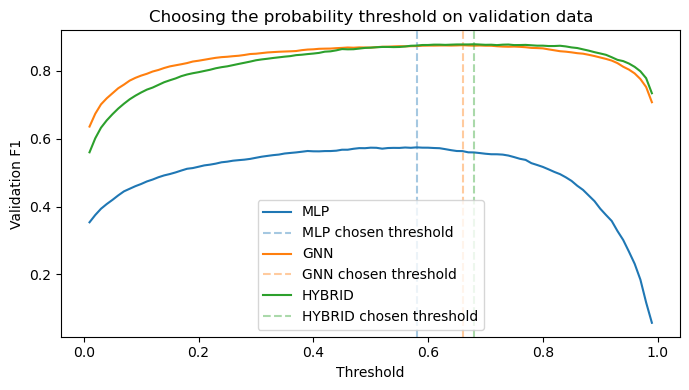

In [15]:
figure, axis = plt.subplots(figsize=(7, 4))
colors = ["tab:blue", "tab:orange", "tab:green"]
for (model_name, table), color in zip(threshold_tables.items(), colors):
    axis.plot(table["threshold"], table["f1"], label=model_name.upper(), color=color)
    axis.axvline(model_metrics[model_name]["threshold"], linestyle="--",  color=color, alpha=0.4, label=f"{model_name.upper()} chosen threshold")

axis.set_title("Choosing the probability threshold on validation data")
axis.set_xlabel("Threshold")
axis.set_ylabel("Validation F1")
axis.legend()
figure.tight_layout()
figure.savefig(FIGURE_DIR / "threshold_selection.png", dpi=180)
plt.show()


## Precision-recall curves

Each point on a curve corresponds to a different threshold. The best curve stays high while moving to the right: it catches many failures without creating too many false alarms.


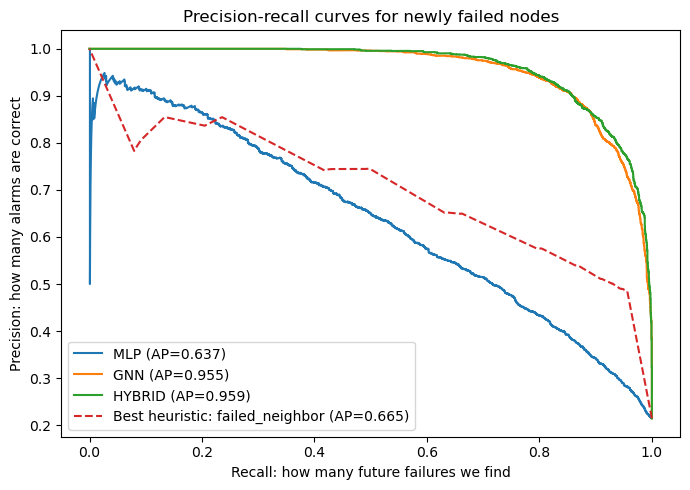

In [16]:
best_baseline = max(baseline_metrics, key=lambda name: baseline_metrics[name]["pr_auc"])

figure, axis = plt.subplots(figsize=(7, 5))
for model_name in MODEL_NAMES:
    predictions = model_predictions[model_name]
    precision, recall, _ = precision_recall_curve(
        predictions["active_target"],
        predictions["active_score"],
    )
    axis.plot(recall, precision, label=f"{model_name.upper()} (AP={model_metrics[model_name]['pr_auc']:.3f})")

predictions = baseline_predictions[best_baseline]
precision, recall, _ = precision_recall_curve(
    predictions["active_target"],
    predictions["active_score"],
)
axis.plot(
    recall,
    precision,
    linestyle="--",
    label=f"Best heuristic: {best_baseline} (AP={baseline_metrics[best_baseline]['pr_auc']:.3f})",
)

axis.set_title("Precision-recall curves for newly failed nodes")
axis.set_xlabel("Recall: how many future failures we find")
axis.set_ylabel("Precision: how many alarms are correct")
axis.legend()
figure.tight_layout()
figure.savefig(FIGURE_DIR / "precision_recall_curves.png", dpi=180)
plt.show()


## Neural models versus simple rules

The bars show test PR-AUC. The small horizontal intervals on neural models are graph-bootstrap 95% intervals. Overlapping intervals mean the available test graphs may not be enough to claim a clear winner.


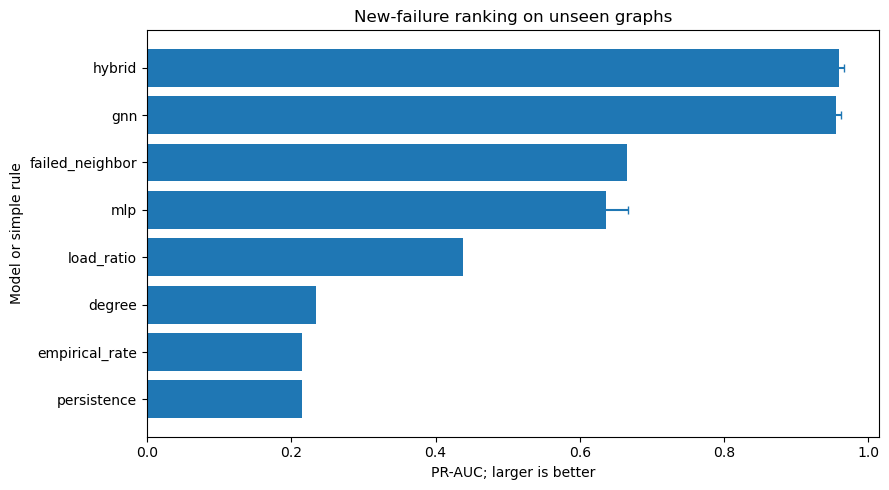

In [17]:
plot_table = comparison.sort_values("pr_auc", ascending=True)
figure, axis = plt.subplots(figsize=(9, 5))
axis.barh(plot_table["model"], plot_table["pr_auc"])

for position, (_, row) in enumerate(plot_table.iterrows()):
    if row["type"] == "neural" and pd.notna(row["pr_auc_ci_lower"]):
        axis.errorbar(
            row["pr_auc"],
            position,
            xerr=[[max(row["pr_auc"] - row["pr_auc_ci_lower"], 0.0)], [max(row["pr_auc_ci_upper"] - row["pr_auc"], 0.0)]],
            fmt="none",
            capsize=3,
        )

axis.set_title("New-failure ranking on unseen graphs")
axis.set_xlabel("PR-AUC; larger is better")
axis.set_ylabel("Model or simple rule")
figure.tight_layout()
figure.savefig(FIGURE_DIR / "comparison_pr_auc.png", dpi=180)
plt.show()


## Confusion Matrix

The confusion matrix counts the four possible outcomes. 
The cascade size scatter predicts the final fraction of failed nodes. Points close to the dashed diagonal are good predictions.

Only one model is shown to avoid repeating nearly identical figures. It is selected using validation PR-AUC, not test PR-AUC.


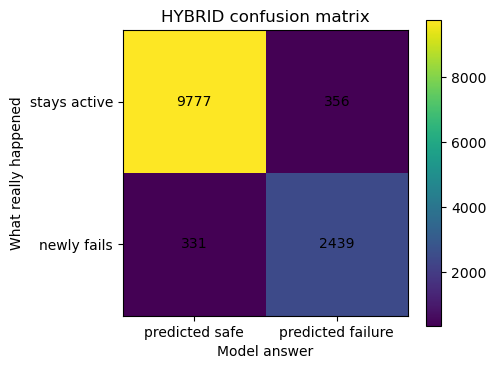

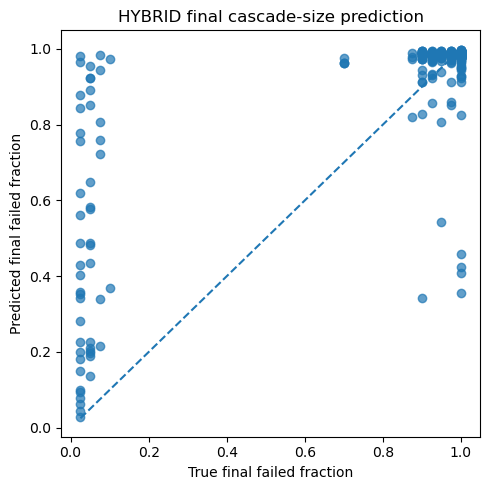

In [18]:
best_model_name = max(
    MODEL_NAMES,
    key=lambda name: model_metrics[name]["validation_pr_auc"],
)
best_predictions = model_predictions[best_model_name]
best_threshold = model_metrics[best_model_name]["threshold"]

prediction = (best_predictions["active_score"] >= best_threshold).astype(int)
matrix = confusion_matrix(best_predictions["active_target"], prediction, labels=[0, 1])

figure, axis = plt.subplots(figsize=(5, 4))
image = axis.imshow(matrix)
for row in range(2):
    for column in range(2):
        axis.text(column, row, str(matrix[row, column]), ha="center", va="center")
axis.set_xticks([0, 1], ["predicted safe", "predicted failure"])
axis.set_yticks([0, 1], ["stays active", "newly fails"])
axis.set_title(f"{best_model_name.upper()} confusion matrix")
axis.set_xlabel("Model answer")
axis.set_ylabel("What really happened")
figure.colorbar(image, ax=axis)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "best_model_confusion_matrix.png", dpi=180)
plt.show()

figure, axis = plt.subplots(figsize=(5, 5))
axis.scatter(
    best_predictions["graph_target"],
    best_predictions["graph_pred"],
    alpha=0.7,
)
lower = float(min(best_predictions["graph_target"].min(), best_predictions["graph_pred"].min()))
upper = float(max(best_predictions["graph_target"].max(), best_predictions["graph_pred"].max()))
axis.plot([lower, upper], [lower, upper], linestyle="--")
axis.set_title(f"{best_model_name.upper()} final cascade-size prediction")
axis.set_xlabel("True final failed fraction")
axis.set_ylabel("Predicted final failed fraction")
figure.tight_layout()
figure.savefig(FIGURE_DIR / "best_model_graph_scatter.png", dpi=180)
plt.show()


## Performance across network conditions

A single overall score can hide a weak graph family or cascade regime. These bars are useful only together with the graph counts shown at the beginning.


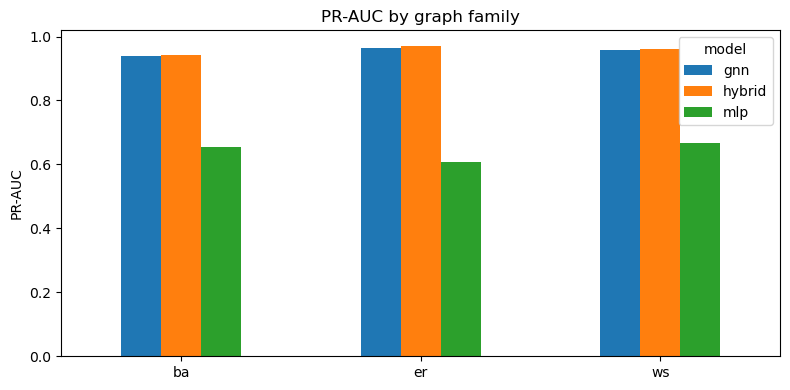

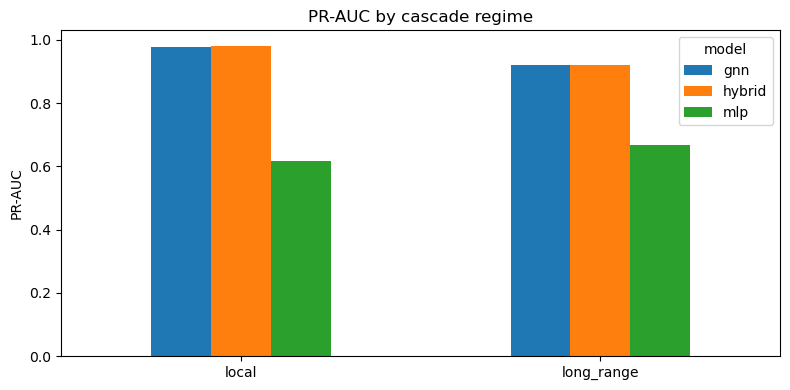

In [19]:
for grouping, title in [
    ("by_family", "PR-AUC by graph family"),
    ("by_regime", "PR-AUC by cascade regime"),
]:
    subset = group_table[group_table["grouping"] == grouping]
    pivot = subset.pivot(index="group", columns="model", values="pr_auc")

    figure, axis = plt.subplots(figsize=(8, 4))
    pivot.plot(kind="bar", ax=axis)
    axis.set_title(title)
    axis.set_xlabel("")
    axis.set_ylabel("PR-AUC")
    axis.tick_params(axis="x", rotation=0)
    figure.tight_layout()
    figure.savefig(FIGURE_DIR / f"{grouping}_pr_auc.png", dpi=180)
    plt.show()
